# Model Comparison: Farm vs Campus vs Campus_dataset_B_3class

Three-dataset cross-environment comparison of every model family trained in
notebooks 07-10. Runs **after** those notebooks have populated `results/Farm/`,
`results/Campus/`, and `results/Campus_dataset_B_3class/`.

## What this notebook does

| § | Section | Datasets |
|---|---------|----------|
| 1 | **Dummy / Chance Baseline** | All 3 (chance level = 1/n_classes per dataset) |
| 2 | **Master Results Table** | All 3, side-by-side macro F1 |
| 3 | **Statistical Significance** | All 3 (heatmap per dataset) |
| 4 | **Noise Sensitivity** | All 3 (overlay curves) |
| 5 | **Sensor Dropout / Ablation** | All 3 (panel per dataset) |
| 6 | **Cross-Day Performance** | All 3 (panel per dataset) |
| 7 | **Per-Class Comparison** | Farm vs Campus_dataset_B_3class only (aligned 3-class subset) |

**Compute source policy**: cached CSVs first; if a CSV is missing for a location
the notebook builds it from per-fold CSVs that already exist (no retraining), or
for sections §4 / §5 it re-trains a RandomForest the first time and saves the
result so re-runs are cached. The original notebook 11 already followed this
pattern for Farm; we just extend it to the new dataset.

**Class-set caveat**: Farm has 3 classes (`dirt_track`, `grass`, `soil`); Campus
has 5 (`cobblestone`, `dry_dirt_track`, `grass`, `muddy_dirt_track`,
`smooth_terrain`); Campus_dataset_B_3class is the 3-class Campus subset
(`dry_dirt_track`, `grass`, `smooth_terrain`). Chance levels differ
(1/3 vs 1/5 vs 1/3) — §1 reports each. §7 uses Campus_B to do an aligned
per-class comparison with Farm (`dry_dirt_track <-> dirt_track`,
`grass <-> grass`; `soil` and `smooth_terrain` are reported separately).


In [18]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import t as t_dist, wilcoxon
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ---------------------------------------------------------------------------
# Project root
# ---------------------------------------------------------------------------
cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / "src").exists() else cwd.parent

# ---------------------------------------------------------------------------
# Three locations in the macro-F1 comparison:
#   Farm                     -> 3-class (dirt_track, grass, soil)
#   Campus                   -> 5-class (cobblestone, dry/muddy_dirt_track,
#                                        grass, smooth_terrain)
#   Campus_dataset_B_3class  -> 3-class Campus subset matching dimensionally
#                               with Farm (used for §7 per-class as well)
# ---------------------------------------------------------------------------
LOCATIONS = ["Farm", "Campus", "Campus_dataset_B_3class"]
PERCLASS_LOCATIONS = ["Farm", "Campus_dataset_B_3class"]  # §7

# Short labels used in plots and table column suffixes
LOC_SHORT = {"Farm": "Farm", "Campus": "Campus", "Campus_dataset_B_3class": "Campus_B"}

CLASS_MAP_FARM_TO_CAMPUS_B = {
    "dirt_track": "dry_dirt_track",
    "grass":      "grass",
    # soil <-> smooth_terrain intentionally NOT mapped
}

RESULTS_DIRS = {loc: PROJECT_ROOT / "results" / loc for loc in LOCATIONS}
DATA_DIRS = {
    "Farm":                    PROJECT_ROOT / "data" / "processed" / "Farm",
    "Campus":                  PROJECT_ROOT / "data" / "processed",   # top-level
    "Campus_dataset_B_3class": PROJECT_ROOT / "data" / "processed",   # filtered in cell 2
}

# dataset_*.csv filename per location
DATA_FILE = {
    "Farm":                    "dataset_A_pruned.csv",
    "Campus":                  "dataset_A_pruned.csv",
    "Campus_dataset_B_3class": "dataset_B_pruned.csv",   # filtered to 3 classes
}

COMP_RESULTS_DIR = PROJECT_ROOT / "results" / "comparison"
COMP_REPORTS_DIR = PROJECT_ROOT / "reports" / "models" / "comparison"
COMP_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
COMP_REPORTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
LABEL_COL    = "label"
RUN_COL      = "run_id"
ALPHA        = 0.05
ID_COLS      = ["window_id", "run_id", "segment_id",
                "label", "t_start", "t_end", "n_samples"]

# Per-location class set — sets chance level reference per dataset
LABELS_BY_LOC = {
    "Farm":   ["dirt_track", "grass", "soil"],
    "Campus": ["cobblestone", "dry_dirt_track", "grass",
               "muddy_dirt_track", "smooth_terrain"],
    "Campus_dataset_B_3class": ["dry_dirt_track", "grass", "smooth_terrain"],
}

# Colour per location, used consistently across plots
LOC_COLOR = {
    "Farm":                    "#4c72b0",  # blue
    "Campus":                  "#dd8452",  # orange
    "Campus_dataset_B_3class": "#55a868",  # green
}

# Date mapping for Campus / Campus_B runs (they share log_* run IDs).
# Farm uses Run1..Run5; its dates come from notebook 09 (see cross_day_pivot.csv).
RUN_TO_DATE = {
    "log_20260223_142511.490": "2026-02-23",
    "log_20260226_102148.990": "2026-02-26",
    "log_20260309_141435.414": "2026-03-09",
    "log_20260326_120021.508": "2026-03-26",
    "Run1": "2026-04-21", "Run2": "2026-04-21",
    "Run3": "2026-04-28", "Run4": "2026-04-28", "Run5": "2026-04-28",
}

sns.set_theme(style="whitegrid", context="notebook")


def _load_csv_safe(path: Path) -> pd.DataFrame | None:
    """Try to load a CSV. Return None and warn if missing or empty."""
    if not path.exists():
        return None
    df = pd.read_csv(path)
    return df if not df.empty else None


def ci95(values) -> tuple[float, float]:
    """95% CI half-width via t-distribution (df = n - 1)."""
    arr = np.asarray(values, dtype=float)
    n = len(arr)
    if n < 2:
        return float(arr.mean()) if n else float("nan"), float("nan")
    se = arr.std(ddof=1) / np.sqrt(n)
    t_crit = float(t_dist.ppf(1 - ALPHA / 2, df=n - 1))
    return float(arr.mean()), float(t_crit * se)


def _make_rf() -> RandomForestClassifier:
    """Standard RF used for §4 noise sweep and §5 sensor dropout (matches notebook 11 default)."""
    return RandomForestClassifier(
        n_estimators=200, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1,
    )


print(f"Project root        : {PROJECT_ROOT}")
print(f"Comparison results  : {COMP_RESULTS_DIR}")
print(f"Comparison reports  : {COMP_REPORTS_DIR}")
print(f"Datasets            : {LOCATIONS}")


Project root        : /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis
Comparison results  : /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/results/comparison
Comparison reports  : /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/comparison
Datasets            : ['Farm', 'Campus', 'Campus_dataset_B_3class']


In [19]:
# ---------------------------------------------------------------------------
# Bulk-load every cached CSV the notebook needs.
# Missing entries are None and trigger an on-the-fly compute in the section.
# ---------------------------------------------------------------------------

metrics_per_fold: dict[str, dict[str, pd.DataFrame | None]] = {}
metrics_summary:  dict[str, dict[str, pd.DataFrame | None]] = {}
extras:           dict[str, dict[str, pd.DataFrame | None]] = {}

for loc in LOCATIONS:
    rd = RESULTS_DIRS[loc]
    metrics_per_fold[loc] = {
        "baseline": _load_csv_safe(rd / "baseline_metrics_per_fold.csv"),
        "tuned":    _load_csv_safe(rd / "tuned_metrics_per_fold.csv"),
        "mlp":      _load_csv_safe(rd / "mlp_metrics_per_fold.csv"),
        "cnn":      _load_csv_safe(rd / "cnn" / "cnn_metrics_per_fold.csv"),
    }
    metrics_summary[loc] = {
        "tuned": _load_csv_safe(rd / "tuned_metrics_summary.csv"),
        "mlp":   _load_csv_safe(rd / "mlp_metrics_summary.csv"),
        "cnn":   _load_csv_safe(rd / "cnn" / "cnn_metrics_summary.csv"),
    }
    extras[loc] = {
        "master":     _load_csv_safe(rd / "master_model_comparison.csv"),
        "sig_p":      _load_csv_safe(rd / "significance_pvalues.csv"),
        "sig_diff":   _load_csv_safe(rd / "significance_f1_diff.csv"),
        "noise":      _load_csv_safe(rd / "noise_sensitivity.csv"),
        "dropout":    _load_csv_safe(rd / "sensor_dropout.csv"),
        "crossday":   _load_csv_safe(rd / "cross_day_performance.csv"),
        "crossday_p": _load_csv_safe(rd / "cross_day_pivot.csv"),
    }

# Per-class tables — only needed in §7, loaded for Farm and Campus_B
perclass_tables: dict[str, dict[str, pd.DataFrame | None]] = {}
for loc in PERCLASS_LOCATIONS:
    rd = RESULTS_DIRS[loc]
    perclass_tables[loc] = {
        m: _load_csv_safe(rd / f"tuned_per_class_metrics_{m.lower()}.csv")
        for m in ["LogisticRegression", "RandomForest", "SVM", "XGBoost"]
    }

# ---------------------------------------------------------------------------
# Raw datasets per location (needed for dummy F1, noise sweep, sensor dropout)
#   Farm:    data/processed/Farm/dataset_A_pruned.csv               (3-class as-is)
#   Campus:  data/processed/dataset_A_pruned.csv                    (5-class as-is)
#   Campus_B: data/processed/dataset_B_pruned.csv  filtered to the  (3-class subset)
#             three Campus_B label values.
# ---------------------------------------------------------------------------
datasets: dict[str, pd.DataFrame] = {}
for loc in LOCATIONS:
    p = DATA_DIRS[loc] / DATA_FILE[loc]
    if not p.exists():
        warnings.warn(f"raw dataset missing for {loc}: {p}")
        continue
    df_loc = pd.read_csv(p)
    if loc == "Campus_dataset_B_3class":
        before = len(df_loc)
        df_loc = df_loc[df_loc[LABEL_COL].isin(LABELS_BY_LOC[loc])].reset_index(drop=True)
        print(f"  Campus_B: filtered {before} -> {len(df_loc)} rows "
              f"keeping {LABELS_BY_LOC[loc]}")
    datasets[loc] = df_loc
    print(f"Loaded {LOC_SHORT[loc]:<9} dataset: {len(df_loc)} windows  "
          f"({len(LABELS_BY_LOC[loc])} classes)")

print()
print("Cached CSV inventory (None = missing, will be computed/skipped per-section):")
for loc in LOCATIONS:
    have = {k: ("ok" if v is not None else "MISSING")
            for k, v in extras[loc].items()}
    print(f"  {LOC_SHORT[loc]:<9}: {have}")


Loaded Farm      dataset: 1583 windows  (3 classes)
Loaded Campus    dataset: 2346 windows  (5 classes)
  Campus_B: filtered 1635 -> 1281 rows keeping ['dry_dirt_track', 'grass', 'smooth_terrain']
Loaded Campus_B  dataset: 1281 windows  (3 classes)

Cached CSV inventory (None = missing, will be computed/skipped per-section):
  Farm     : {'master': 'ok', 'sig_p': 'ok', 'sig_diff': 'ok', 'noise': 'ok', 'dropout': 'ok', 'crossday': 'ok', 'crossday_p': 'ok'}
  Campus   : {'master': 'ok', 'sig_p': 'ok', 'sig_diff': 'ok', 'noise': 'ok', 'dropout': 'ok', 'crossday': 'ok', 'crossday_p': 'ok'}
  Campus_B : {'master': 'ok', 'sig_p': 'ok', 'sig_diff': 'ok', 'noise': 'ok', 'dropout': 'ok', 'crossday': 'MISSING', 'crossday_p': 'ok'}


## §1 - Dummy / Chance Baseline (per dataset)

Chance level depends on class count. Farm and Campus_B are 3-class problems so a
balanced random predictor sits near macro F1 = 1/3; Campus is 5-class so the
balanced reference is 1/5. The stratified dummy lands below chance because it
draws labels from the *training* class frequencies, which are imbalanced.

All three datasets use the same LORO-CV protocol (one held-out run per fold).


In [20]:
# ---------------------------------------------------------------------------
# Recompute dummy F1 per location, stack the per-fold rows.
# Iterate over whatever run IDs the dataset actually has (Farm has Run1..Run5,
# Campus/Campus_B use log_<timestamp> IDs).
# ---------------------------------------------------------------------------

def _compute_dummy_per_fold(df_loc: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    rows = []
    runs_in_df = sorted(df_loc[RUN_COL].astype(str).unique().tolist())
    for test_run in runs_in_df:
        train_mask = df_loc[RUN_COL].astype(str) != test_run
        test_mask  = ~train_mask
        if test_mask.sum() == 0 or train_mask.sum() == 0:
            continue
        X_train = df_loc.loc[train_mask, feature_cols].to_numpy(dtype=float)
        X_test  = df_loc.loc[test_mask,  feature_cols].to_numpy(dtype=float)
        y_train = df_loc.loc[train_mask, LABEL_COL].to_numpy()
        y_test  = df_loc.loc[test_mask,  LABEL_COL].to_numpy()

        # Stratified — average over 20 seeds (stochastic)
        f1s_strat = [
            f1_score(
                y_test,
                DummyClassifier(strategy="stratified", random_state=s)
                    .fit(X_train, y_train).predict(X_test),
                average="macro", zero_division=0,
                labels=list(np.unique(y_test)),
            )
            for s in range(20)
        ]
        rows.append({
            "model": "Dummy (stratified)", "test_run": test_run,
            "macro_f1": float(np.mean(f1s_strat)),
        })

        # Most-frequent — deterministic
        d = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
        y_pred = d.predict(X_test)
        rows.append({
            "model": "Dummy (most_frequent)", "test_run": test_run,
            "macro_f1": float(f1_score(
                y_test, y_pred, average="macro", zero_division=0,
                labels=list(np.unique(y_test)),
            )),
        })
    return pd.DataFrame(rows)


dummy_blocks = []
dummy_per_loc: dict[str, pd.DataFrame] = {}
for loc, df_loc in datasets.items():
    feat_cols = [c for c in df_loc.columns if c not in ID_COLS]
    dpf = _compute_dummy_per_fold(df_loc, feat_cols)
    dummy_per_loc[loc] = dpf
    dpf = dpf.assign(location=loc, chance_level=1.0 / len(LABELS_BY_LOC[loc]))
    dummy_blocks.append(dpf)

dummy_pf_all = pd.concat(dummy_blocks, ignore_index=True)

dummy_summary = (
    dummy_pf_all
    .groupby(["location", "model"])
    .agg(macro_f1_mean=("macro_f1", "mean"),
         macro_f1_std=("macro_f1", "std"),
         folds=("test_run", "nunique"),
         chance_level=("chance_level", "first"))
    .reset_index()
)

print("=== Dummy / chance baseline per dataset ===")
print(dummy_summary.round(4).to_string(index=False))

out_csv = COMP_RESULTS_DIR / "dummy_comparison.csv"
dummy_summary.to_csv(out_csv, index=False)
print(f"\nSaved -> {out_csv}")


=== Dummy / chance baseline per dataset ===
               location                 model  macro_f1_mean  macro_f1_std  folds  chance_level
                 Campus Dummy (most_frequent)         0.0245        0.0489      4        0.2000
                 Campus    Dummy (stratified)         0.1763        0.0362      4        0.2000
Campus_dataset_B_3class Dummy (most_frequent)         0.0383        0.0767      4        0.3333
Campus_dataset_B_3class    Dummy (stratified)         0.3471        0.1265      4        0.3333
                   Farm Dummy (most_frequent)         0.2079        0.0360      5        0.3333
                   Farm    Dummy (stratified)         0.3200        0.0103      5        0.3333

Saved -> /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/results/comparison/dummy_comparison.csv


## §2 - Master Results Table (Farm vs Campus vs Campus_B)

Each location either has its own cached `master_model_comparison.csv` or it is
built on-the-fly from `tuned_metrics_per_fold.csv` + the MLP/CNN per-fold CSVs
(same code path as the original notebook 11). Campus_B currently has no cached
master, so it is built here and saved to disk.

The joined table reports macro F1 (mean +/- 95% CI half-width, t-distribution
with df = 4) for each model on each dataset. Two delta columns make the gaps
explicit:
- `Delta_FvC`  = Farm - Campus
- `Delta_FvCB` = Farm - Campus_B


In [21]:
# ---------------------------------------------------------------------------
# If a location's master CSV is missing, build it from per-fold + summary CSVs
# and the dummy results we computed in §1. Same layout as the original
# notebook 11 cell 6 output.
# ---------------------------------------------------------------------------

def _build_master(loc: str) -> pd.DataFrame:
    tuned_pf  = metrics_per_fold[loc]["tuned"]
    tuned_sum = metrics_summary[loc]["tuned"]
    mlp_pf    = metrics_per_fold[loc]["mlp"]
    mlp_sum   = metrics_summary[loc]["mlp"]
    cnn_pf    = metrics_per_fold[loc]["cnn"]
    dpf       = dummy_per_loc.get(loc)

    if any(x is None for x in (tuned_pf, tuned_sum, mlp_pf, mlp_sum, cnn_pf, dpf)):
        raise ValueError(f"Cannot build master for {loc} — missing per-fold CSVs.")

    rows = []
    # Best tuned classical model per family
    best_tuned = (tuned_sum.sort_values("macro_f1_mean", ascending=False)
                  .groupby("model", sort=False).first().reset_index())
    for _, br in best_tuned.iterrows():
        mask = ((tuned_pf["model"] == br["model"]) &
                (tuned_pf["feature_set"] == br["feature_set"]) &
                (tuned_pf["imbalance"]   == br["imbalance"]))
        folds = tuned_pf.loc[mask, "macro_f1"].tolist()
        mean_f, margin = ci95(folds)
        rows.append({
            "Model": br["model"],
            "Config": f"{br['feature_set']}, {br['imbalance']}",
            "F1 mean": mean_f, "95% CI margin": margin,
            "F1 std": float(np.std(folds, ddof=1)),
            "Worst fold F1": float(min(folds)), "Folds": len(folds),
        })
    # MLP
    best_mlp = mlp_sum.loc[mlp_sum["macro_f1_mean"].idxmax()]
    mlp_folds = mlp_pf.loc[mlp_pf["feature_set"] == best_mlp["feature_set"], "macro_f1"].tolist()
    mean_f, margin = ci95(mlp_folds)
    rows.append({
        "Model": "MLP", "Config": str(best_mlp["feature_set"]),
        "F1 mean": mean_f, "95% CI margin": margin,
        "F1 std": float(np.std(mlp_folds, ddof=1)),
        "Worst fold F1": float(min(mlp_folds)), "Folds": len(mlp_folds),
    })
    # CNN
    cnn_folds = cnn_pf["macro_f1"].tolist()
    mean_f, margin = ci95(cnn_folds)
    rows.append({
        "Model": "CNN", "Config": "raw signal (5 ch)",
        "F1 mean": mean_f, "95% CI margin": margin,
        "F1 std": float(np.std(cnn_folds, ddof=1)),
        "Worst fold F1": float(min(cnn_folds)), "Folds": len(cnn_folds),
    })
    # Dummy anchors
    for strategy in ("stratified", "most_frequent"):
        sub = dpf.loc[dpf["model"] == f"Dummy ({strategy})", "macro_f1"].tolist()
        if not sub:
            continue
        mean_f, margin = ci95(sub)
        rows.append({
            "Model": f"Dummy ({strategy})", "Config": "-",
            "F1 mean": mean_f, "95% CI margin": margin,
            "F1 std": float(np.std(sub, ddof=1)),
            "Worst fold F1": float(min(sub)), "Folds": len(sub),
        })
    return (pd.DataFrame(rows)
            .sort_values("F1 mean", ascending=False).reset_index(drop=True))


# Build or load the master for each location
master_by_loc: dict[str, pd.DataFrame] = {}
for loc in LOCATIONS:
    if extras[loc]["master"] is not None:
        master_by_loc[loc] = extras[loc]["master"]
    else:
        print(f"Building master for {loc} from per-fold CSVs...")
        master_by_loc[loc] = _build_master(loc)
        out = RESULTS_DIRS[loc] / "master_model_comparison.csv"
        master_by_loc[loc].to_csv(out, index=False)
        print(f"  saved -> {out}")

# Three-way join on Model
def _rename(df: pd.DataFrame, suf: str) -> pd.DataFrame:
    return df.rename(columns={
        "Config": f"Config_{suf}", "F1 mean": f"F1_{suf}",
        "95% CI margin": f"CI95_{suf}", "F1 std": f"Std_{suf}",
        "Worst fold F1": f"WorstFold_{suf}",
    })[["Model", f"Config_{suf}", f"F1_{suf}", f"CI95_{suf}",
        f"Std_{suf}", f"WorstFold_{suf}"]]

mf  = _rename(master_by_loc["Farm"],                    "Farm")
mc  = _rename(master_by_loc["Campus"],                  "Campus")
mcb = _rename(master_by_loc["Campus_dataset_B_3class"], "CampusB")

master_compare = (
    mf.merge(mc, on="Model", how="outer")
      .merge(mcb, on="Model", how="outer")
      .assign(
          Delta_FvC =lambda x: x["F1_Farm"] - x["F1_Campus"],
          Delta_FvCB=lambda x: x["F1_Farm"] - x["F1_CampusB"],
      )
      .sort_values("F1_Farm", ascending=False, na_position="last")
      .reset_index(drop=True)
)

# Pretty display
disp = master_compare.copy()
for suf in ["Farm", "Campus", "CampusB"]:
    disp[f"{suf} (mean+/-CI95)"] = (
        disp[f"F1_{suf}"].map("{:.3f}".format)
        + " +/- " + disp[f"CI95_{suf}"].map("{:.3f}".format)
    )
disp["Delta(F-C)"]  = disp["Delta_FvC"].map("{:+.3f}".format)
disp["Delta(F-CB)"] = disp["Delta_FvCB"].map("{:+.3f}".format)
disp = disp[[
    "Model",
    "Farm (mean+/-CI95)", "Campus (mean+/-CI95)", "CampusB (mean+/-CI95)",
    "Delta(F-C)", "Delta(F-CB)",
]]

print("=== Master Model Comparison: Farm vs Campus vs Campus_B ===")
print("5-fold LORO-CV per dataset. Delta > 0 = model is worse on the right side.\n")
print(disp.to_string(index=False))

out_csv = COMP_RESULTS_DIR / "master_model_comparison_farm_vs_campus.csv"
master_compare.to_csv(out_csv, index=False)
print(f"\nSaved -> {out_csv}")


=== Master Model Comparison: Farm vs Campus vs Campus_B ===
5-fold LORO-CV per dataset. Delta > 0 = model is worse on the right side.

                Model Farm (mean+/-CI95) Campus (mean+/-CI95) CampusB (mean+/-CI95) Delta(F-C) Delta(F-CB)
                  SVM    0.866 +/- 0.075      0.728 +/- 0.134       0.986 +/- 0.030     +0.138      -0.120
   LogisticRegression    0.865 +/- 0.084      0.765 +/- 0.151       0.984 +/- 0.020     +0.100      -0.119
              XGBoost    0.861 +/- 0.060      0.765 +/- 0.178       0.982 +/- 0.023     +0.096      -0.121
                  CNN    0.849 +/- 0.100      0.757 +/- 0.191       0.952 +/- 0.081     +0.093      -0.103
                  MLP    0.840 +/- 0.088      0.766 +/- 0.165       0.965 +/- 0.058     +0.074      -0.125
         RandomForest    0.840 +/- 0.059      0.759 +/- 0.152       0.983 +/- 0.033     +0.081      -0.143
   Dummy (stratified)    0.320 +/- 0.013      0.201 +/- 0.031       0.347 +/- 0.201     +0.119      -0.027
Dummy (mo

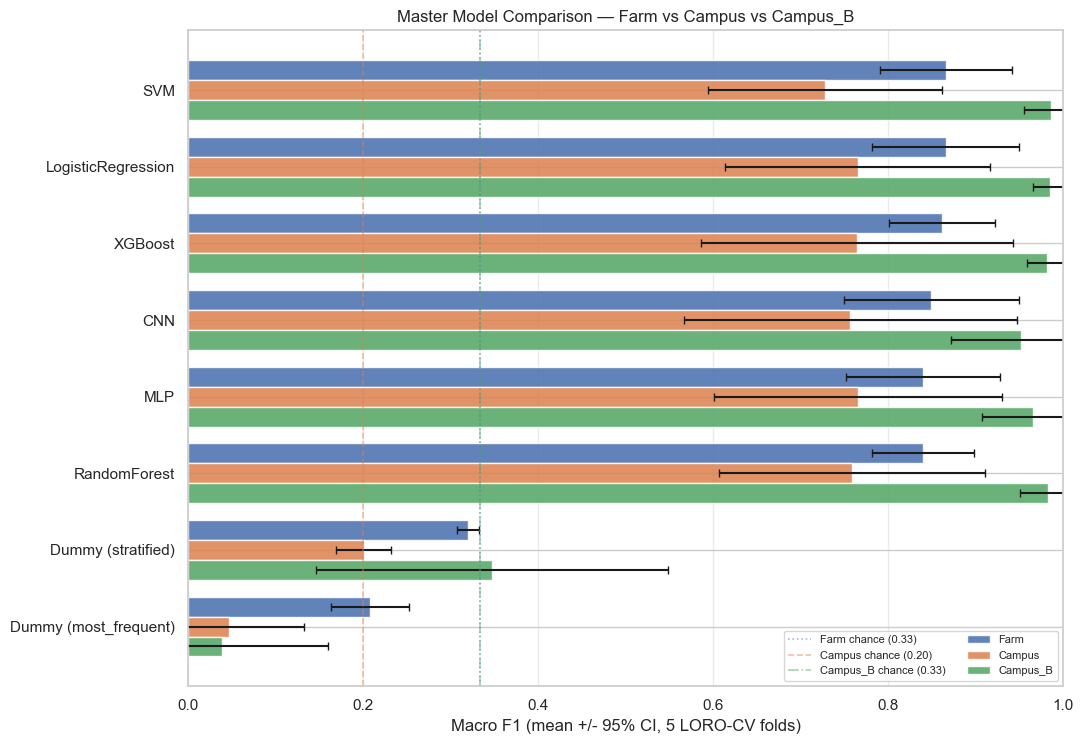

Saved -> /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/comparison/master_comparison_bars.png


In [22]:
# ---------------------------------------------------------------------------
# Grouped horizontal bars: 3 bars per model (Farm, Campus, Campus_B).
# Ranking is by Farm F1 so the eye reads top-to-bottom best->worst on Farm.
# ---------------------------------------------------------------------------

_plot_df = master_compare.dropna(
    subset=["F1_Farm", "F1_Campus", "F1_CampusB"]
).copy()
models = _plot_df["Model"].tolist()
n = len(models)
y = np.arange(n)
h = 0.26  # narrower since we have 3 bars per model

fig, ax = plt.subplots(figsize=(11, 0.7 * n + 2))
ax.barh(y - h, _plot_df["F1_Farm"],    xerr=_plot_df["CI95_Farm"],
        height=h, color=LOC_COLOR["Farm"],                    label="Farm",
        capsize=3, alpha=0.88)
ax.barh(y,     _plot_df["F1_Campus"],  xerr=_plot_df["CI95_Campus"],
        height=h, color=LOC_COLOR["Campus"],                  label="Campus",
        capsize=3, alpha=0.88)
ax.barh(y + h, _plot_df["F1_CampusB"], xerr=_plot_df["CI95_CampusB"],
        height=h, color=LOC_COLOR["Campus_dataset_B_3class"], label="Campus_B",
        capsize=3, alpha=0.88)

# Per-dataset chance reference lines
for loc, ls in [("Farm", ":"), ("Campus", "--"), ("Campus_dataset_B_3class", "-.")]:
    ax.axvline(1.0 / len(LABELS_BY_LOC[loc]),
               color=LOC_COLOR[loc], linestyle=ls, linewidth=1.2, alpha=0.5,
               label=f"{LOC_SHORT[loc]} chance ({1/len(LABELS_BY_LOC[loc]):.2f})")

ax.set_yticks(y, models)
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel("Macro F1 (mean +/- 95% CI, 5 LORO-CV folds)")
ax.set_title("Master Model Comparison — Farm vs Campus vs Campus_B")
ax.legend(frameon=True, loc="lower right", fontsize=8, ncol=2)
ax.grid(axis="x", alpha=0.4)
plt.tight_layout()
out_png = COMP_REPORTS_DIR / "master_comparison_bars.png"
plt.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {out_png}")


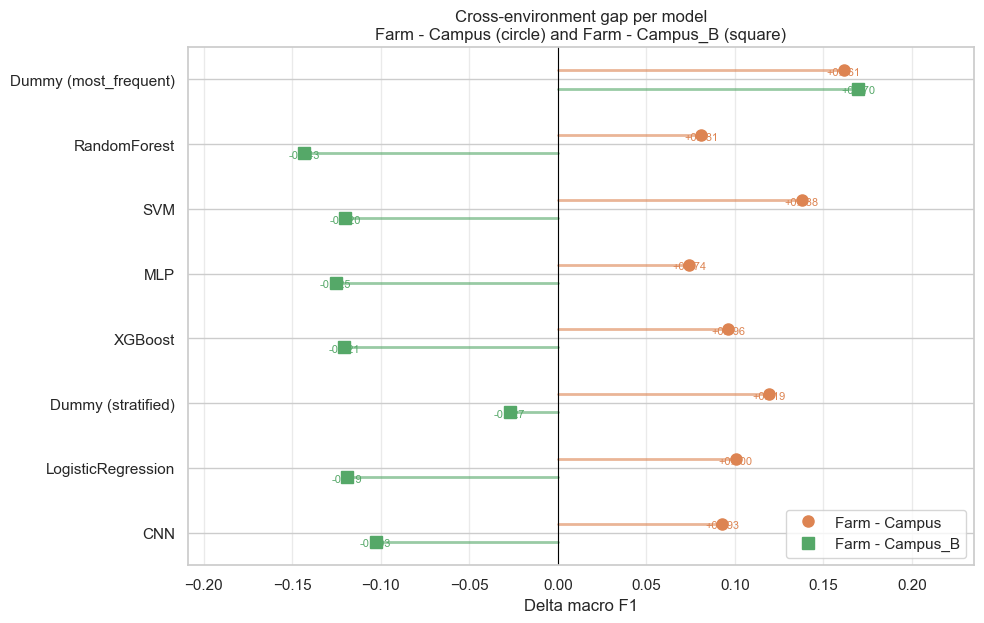

Saved -> /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/comparison/master_comparison_delta.png


In [23]:
# ---------------------------------------------------------------------------
# Two-delta dot chart: Farm-Campus and Farm-CampusB per model.
# Positive delta = model is worse on the second dataset.
# Models sorted by max(|delta|) so the most environment-sensitive sit on top.
# ---------------------------------------------------------------------------

_d = master_compare.dropna(subset=["Delta_FvC", "Delta_FvCB"]).copy()
_d["sort_key"] = _d[["Delta_FvC", "Delta_FvCB"]].abs().max(axis=1)
_d = _d.sort_values("sort_key", ascending=False)
y = np.arange(len(_d))

fig, ax = plt.subplots(figsize=(10, 0.55 * len(_d) + 2))
for yi, (_, r) in zip(y, _d.iterrows()):
    for delta, marker, color, label, off in [
        (r["Delta_FvC"],  "o", LOC_COLOR["Campus"],
         "Farm - Campus",   -0.14),
        (r["Delta_FvCB"], "s", LOC_COLOR["Campus_dataset_B_3class"],
         "Farm - Campus_B", +0.14),
    ]:
        ax.plot([0, delta], [yi + off, yi + off], color=color, lw=2, alpha=0.6)
        ax.plot(delta, yi + off, marker, color=color, markersize=8,
                label=label if yi == 0 else None)
        ax.text(delta, yi + off - 0.05, f"{delta:+.3f}",
                ha="center", va="top", fontsize=8, color=color)

ax.axvline(0, color="black", linewidth=0.8)
ax.set_yticks(y, _d["Model"])
ax.invert_yaxis()
ax.set_xlabel("Delta macro F1")
ax.set_title("Cross-environment gap per model\n"
             "Farm - Campus (circle) and Farm - Campus_B (square)")
ax.grid(axis="x", alpha=0.4)
ax.legend(frameon=True, loc="lower right")
xpad = 0.04 + 0.15 * float(_d[["Delta_FvC", "Delta_FvCB"]].abs().max().max())
ax.set_xlim(min(_d[["Delta_FvC", "Delta_FvCB"]].min().min(), 0) - xpad,
            max(_d[["Delta_FvC", "Delta_FvCB"]].max().max(), 0) + xpad)
plt.tight_layout()
out_png = COMP_REPORTS_DIR / "master_comparison_delta.png"
plt.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {out_png}")


## §3 - Statistical Significance (per dataset)

Pairwise Wilcoxon signed-rank tests on the 5 fold-level macro F1 values for each
(model, dataset) pair. Cached significance CSVs are loaded if present; otherwise
computed here from the per-fold CSVs that already exist for that location (no
retraining required).

**Power caveat (unchanged)**: with 5 folds, the minimum achievable two-sided
Wilcoxon p-value is 0.0625 — no comparison can reach alpha=0.05 by this test
alone. We compare the *pattern* of p-values across datasets rather than passing /
failing thresholds.


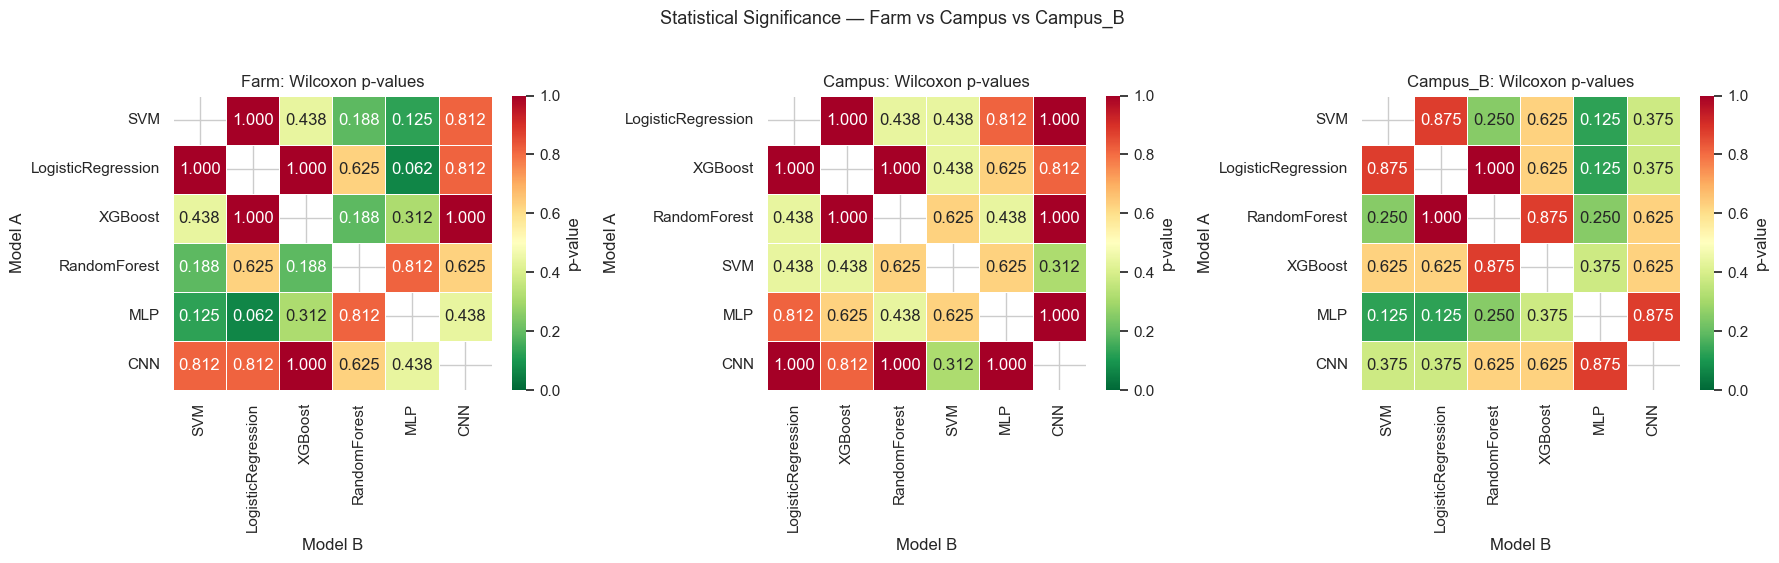

Saved -> /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/comparison/significance_farm_vs_campus.png


In [24]:
# ---------------------------------------------------------------------------
# Build or load a (p_df, diff_df) pair per location.
# For locations where the cached CSV is missing, recompute from per-fold F1.
# ---------------------------------------------------------------------------

def _candidates_for_loc(loc: str) -> dict[str, np.ndarray]:
    tuned_pf  = metrics_per_fold[loc]["tuned"]
    tuned_sum = metrics_summary[loc]["tuned"]
    mlp_pf    = metrics_per_fold[loc]["mlp"]
    mlp_sum   = metrics_summary[loc]["mlp"]
    cnn_pf    = metrics_per_fold[loc]["cnn"]
    out = {}
    if tuned_pf is not None and tuned_sum is not None:
        best_tuned = (tuned_sum.sort_values("macro_f1_mean", ascending=False)
                      .groupby("model", sort=False).first().reset_index())
        for _, br in best_tuned.iterrows():
            mask = ((tuned_pf["model"] == br["model"]) &
                    (tuned_pf["feature_set"] == br["feature_set"]) &
                    (tuned_pf["imbalance"] == br["imbalance"]))
            out[br["model"]] = tuned_pf.loc[mask, "macro_f1"].to_numpy()
    if mlp_pf is not None and mlp_sum is not None:
        bm = mlp_sum.loc[mlp_sum["macro_f1_mean"].idxmax()]
        out["MLP"] = mlp_pf.loc[mlp_pf["feature_set"] == bm["feature_set"],
                                "macro_f1"].to_numpy()
    if cnn_pf is not None:
        out["CNN"] = cnn_pf["macro_f1"].to_numpy()
    return out


def _build_significance(loc: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    candidates = _candidates_for_loc(loc)
    names = list(candidates.keys())
    P = np.full((len(names), len(names)), np.nan)
    D = np.full((len(names), len(names)), np.nan)
    for i, a in enumerate(names):
        for j, b in enumerate(names):
            if i == j: continue
            D[i, j] = candidates[a].mean() - candidates[b].mean()
            try:
                _, pval = wilcoxon(candidates[a], candidates[b], alternative="two-sided")
                P[i, j] = pval
            except ValueError:
                P[i, j] = 1.0
    p_df = pd.DataFrame(P, index=names, columns=names)
    d_df = pd.DataFrame(D, index=names, columns=names)
    return p_df, d_df


sig_by_loc: dict[str, tuple[pd.DataFrame, pd.DataFrame]] = {}
for loc in LOCATIONS:
    if extras[loc]["sig_p"] is not None and extras[loc]["sig_diff"] is not None:
        p = extras[loc]["sig_p"].set_index(extras[loc]["sig_p"].columns[0])
        d = extras[loc]["sig_diff"].set_index(extras[loc]["sig_diff"].columns[0])
        sig_by_loc[loc] = (p, d)
    else:
        print(f"Computing significance matrices for {loc}...")
        p, d = _build_significance(loc)
        sig_by_loc[loc] = (p, d)
        p.to_csv(RESULTS_DIRS[loc] / "significance_pvalues.csv")
        d.to_csv(RESULTS_DIRS[loc] / "significance_f1_diff.csv")
        print(f"  saved sig_pvalues / sig_f1_diff -> {RESULTS_DIRS[loc]}")

# 3-panel heatmap
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, loc in zip(axes, LOCATIONS):
    p_df, _ = sig_by_loc[loc]
    mask = np.eye(len(p_df), dtype=bool)
    sns.heatmap(p_df.astype(float), ax=ax,
                annot=True, fmt=".3f", cmap="RdYlGn_r",
                vmin=0, vmax=1, mask=mask, linewidths=0.5,
                cbar_kws={"label": "p-value"})
    ax.set_title(f"{LOC_SHORT[loc]}: Wilcoxon p-values")
    ax.set_xlabel("Model B"); ax.set_ylabel("Model A")
fig.suptitle("Statistical Significance — Farm vs Campus vs Campus_B",
             y=1.02, fontsize=13)
plt.tight_layout()
out_png = COMP_REPORTS_DIR / "significance_farm_vs_campus.png"
plt.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {out_png}")


## §4 - Noise Sensitivity (overlay curves, all 3 datasets)

Gaussian noise is injected into test-time features (scaled per-feature by the
training std). Macro F1 is averaged over 10 noise realisations per (fold, sigma).
Model is RandomForest (balanced, 200 trees) on each dataset.

Locations with a cached `noise_sensitivity.csv` are loaded directly. Campus_B has
no cache so the sweep is run inline and saved to `results/Campus_dataset_B_3class/`.


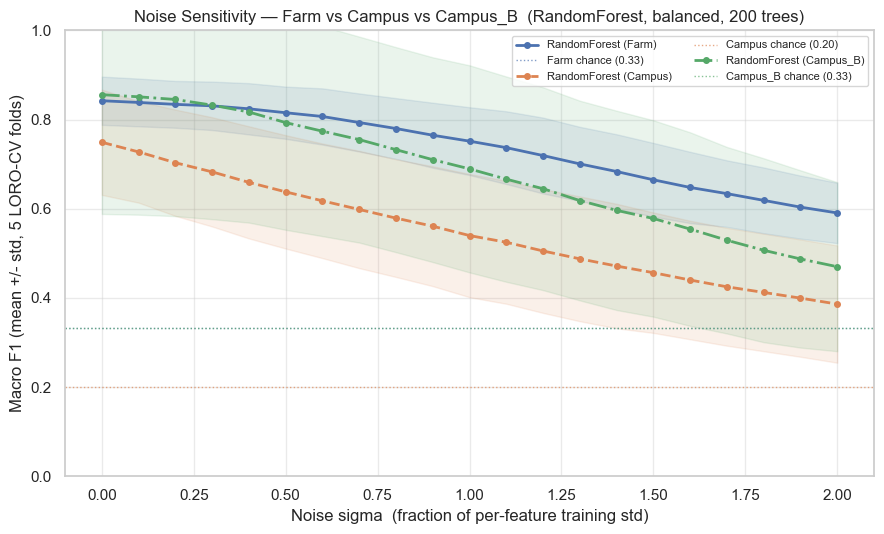

Saved -> /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/comparison/noise_sensitivity_farm_vs_campus.png
Saved -> /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/results/comparison/noise_sensitivity_farm_vs_campus.csv


In [25]:
# ---------------------------------------------------------------------------
# Run the noise sweep for any location whose CSV is missing.
# Same protocol as the original notebook 11 cell 12.
# ---------------------------------------------------------------------------

NOISE_LEVELS = np.round(np.arange(0.0, 2.05, 0.1), 2)
N_NOISE_REPS = 10

def _run_noise_sweep(df_loc: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    runs_in_df = sorted(df_loc[RUN_COL].astype(str).unique().tolist())
    rows = []
    for sigma in NOISE_LEVELS:
        fold_f1s = []
        for test_run in runs_in_df:
            train_mask = df_loc[RUN_COL].astype(str) != test_run
            test_mask  = ~train_mask
            X_train = df_loc.loc[train_mask, feature_cols].to_numpy(dtype=float)
            X_test  = df_loc.loc[test_mask,  feature_cols].to_numpy(dtype=float)
            y_train = df_loc.loc[train_mask, LABEL_COL].to_numpy()
            y_test  = df_loc.loc[test_mask,  LABEL_COL].to_numpy()

            le     = LabelEncoder().fit(y_train)
            scaler = StandardScaler().fit(X_train)
            clf    = _make_rf().fit(scaler.transform(X_train), le.transform(y_train))

            rep_f1s = []
            for rep in range(N_NOISE_REPS):
                rng = np.random.default_rng(rep)
                noise = rng.standard_normal(X_test.shape) * sigma * scaler.scale_
                X_noisy = scaler.transform(X_test + noise)
                y_pred = le.inverse_transform(clf.predict(X_noisy))
                rep_f1s.append(f1_score(
                    y_test, y_pred, average="macro", zero_division=0,
                    labels=list(np.unique(y_test)),
                ))
            fold_f1s.append(float(np.mean(rep_f1s)))
        rows.append({
            "sigma":        sigma,
            "macro_f1_mean": float(np.mean(fold_f1s)),
            "macro_f1_std":  float(np.std(fold_f1s, ddof=1)),
            "macro_f1_min":  float(min(fold_f1s)),
        })
    return pd.DataFrame(rows)


noise_by_loc: dict[str, pd.DataFrame] = {}
for loc in LOCATIONS:
    if extras[loc]["noise"] is not None:
        noise_by_loc[loc] = extras[loc]["noise"]
        continue
    if loc not in datasets:
        continue
    print(f"Running noise sweep for {loc} (this can take a few minutes)...")
    feat_cols = [c for c in datasets[loc].columns if c not in ID_COLS]
    nd = _run_noise_sweep(datasets[loc], feat_cols)
    noise_by_loc[loc] = nd
    out = RESULTS_DIRS[loc] / "noise_sensitivity.csv"
    nd.to_csv(out, index=False)
    print(f"  saved -> {out}")

# Overlay plot
fig, ax = plt.subplots(figsize=(9, 5.5))
linestyles = {"Farm": "-", "Campus": "--", "Campus_dataset_B_3class": "-."}
tidy_blocks: list[pd.DataFrame] = []
for loc in LOCATIONS:
    nd = noise_by_loc.get(loc)
    if nd is None:
        continue
    c = LOC_COLOR[loc]
    ax.plot(nd["sigma"], nd["macro_f1_mean"],
            marker="o", linewidth=2, markersize=4,
            linestyle=linestyles[loc], color=c,
            label=f"RandomForest ({LOC_SHORT[loc]})")
    ax.fill_between(nd["sigma"],
                    nd["macro_f1_mean"] - nd["macro_f1_std"],
                    nd["macro_f1_mean"] + nd["macro_f1_std"],
                    alpha=0.12, color=c)
    chance = 1.0 / len(LABELS_BY_LOC[loc])
    ax.axhline(chance, color=c, linestyle=":", linewidth=1.0, alpha=0.7,
               label=f"{LOC_SHORT[loc]} chance ({chance:.2f})")
    block = nd.copy(); block["location"] = loc
    tidy_blocks.append(block)

ax.set_xlabel("Noise sigma  (fraction of per-feature training std)")
ax.set_ylabel("Macro F1 (mean +/- std, 5 LORO-CV folds)")
ax.set_title("Noise Sensitivity — Farm vs Campus vs Campus_B  (RandomForest, balanced, 200 trees)")
ax.set_ylim(0, 1)
ax.legend(frameon=True, loc="upper right", fontsize=8, ncol=2)
ax.grid(alpha=0.4)
plt.tight_layout()
out_png = COMP_REPORTS_DIR / "noise_sensitivity_farm_vs_campus.png"
plt.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()

if tidy_blocks:
    tidy = pd.concat(tidy_blocks, ignore_index=True)
    out_csv = COMP_RESULTS_DIR / "noise_sensitivity_farm_vs_campus.csv"
    tidy.to_csv(out_csv, index=False)
    print(f"Saved -> {out_png}")
    print(f"Saved -> {out_csv}")


## §5 - Sensor Dropout / Ablation (3-panel, all datasets)

Two perturbations per sensor group: **test-time zero** (model trained on all
features; sensor columns zeroed at test time, simulating sensor failure at
deployment) and **full ablation** (sensor columns removed at both training and
test).

| Sensor group | Feature prefix(es) |
|---|---|
| Accelerometer | `ax_*`, `ay_*`, `az_*`, `acc_mag_*` |
| Gyroscope     | `gx_*`, `gy_*`, `gz_*`, `gyro_mag_*` |
| Odometry      | `odom_*` |

Cached `sensor_dropout.csv` is loaded if present; Campus_B is run inline and saved.


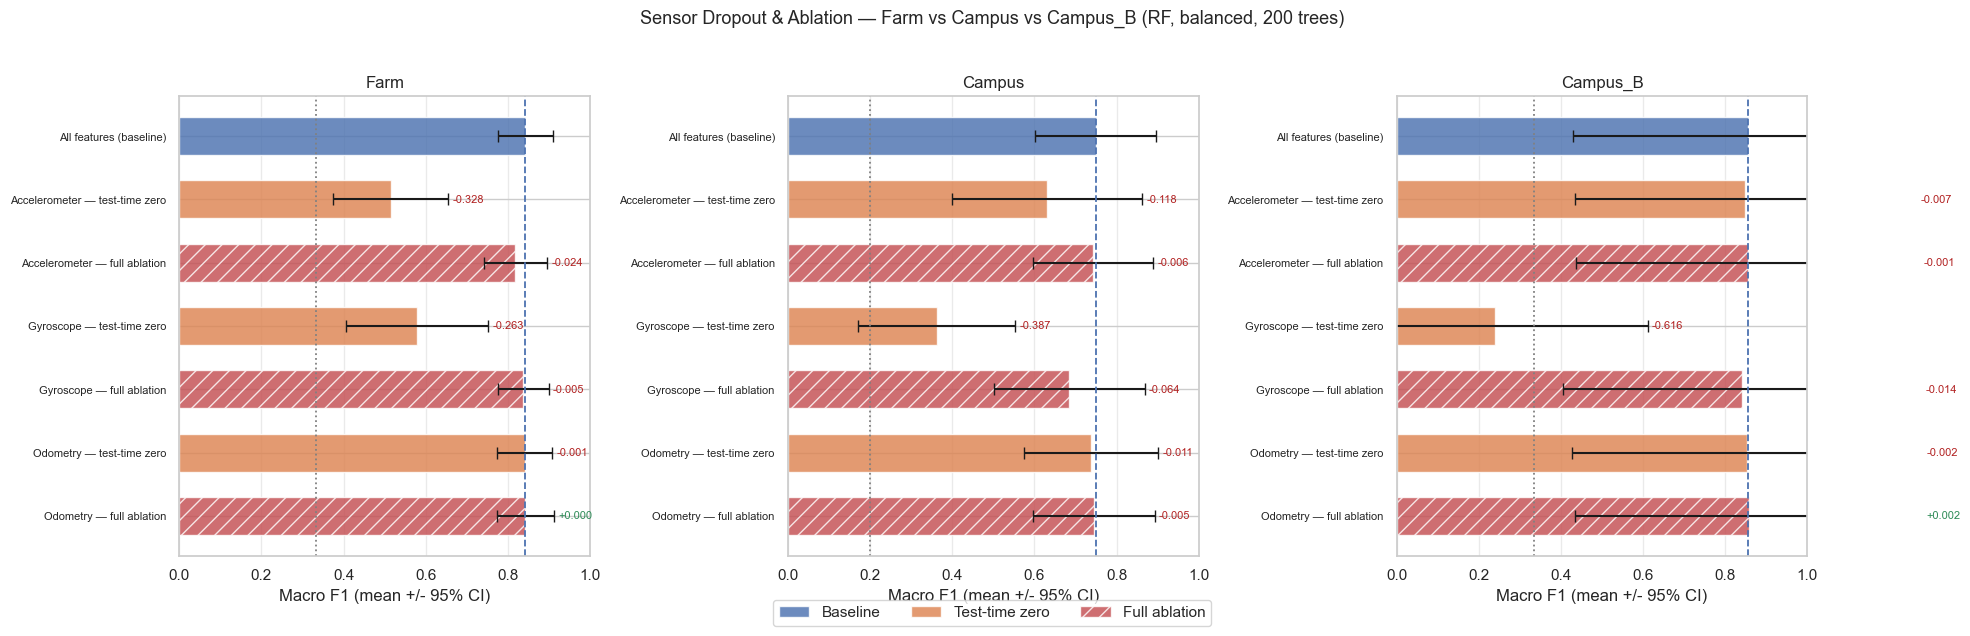

Saved -> /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/comparison/sensor_dropout_farm_vs_campus.png


In [26]:
# ---------------------------------------------------------------------------
# Run dropout study for any location whose CSV is missing.
# ---------------------------------------------------------------------------

def _sensor_groups_for(feature_cols: list[str]) -> dict[str, list[str]]:
    return {
        "Accelerometer": [c for c in feature_cols if c.startswith(("ax_", "ay_", "az_", "acc_mag_"))],
        "Gyroscope":     [c for c in feature_cols if c.startswith(("gx_", "gy_", "gz_", "gyro_mag_"))],
        "Odometry":      [c for c in feature_cols if c.startswith("odom_")],
    }

def _run_loro_cv(df_loc: pd.DataFrame, col_list: list[str],
                 zero_at_test: list[str] | None = None) -> list[float]:
    runs_in_df = sorted(df_loc[RUN_COL].astype(str).unique().tolist())
    fold_f1s = []
    for test_run in runs_in_df:
        train_mask = df_loc[RUN_COL].astype(str) != test_run
        test_mask  = ~train_mask
        X_train = df_loc.loc[train_mask, col_list].to_numpy(dtype=float)
        X_test  = df_loc.loc[test_mask,  col_list].to_numpy(dtype=float)
        y_train = df_loc.loc[train_mask, LABEL_COL].to_numpy()
        y_test  = df_loc.loc[test_mask,  LABEL_COL].to_numpy()
        if zero_at_test:
            idx = [col_list.index(c) for c in zero_at_test if c in col_list]
            X_test = X_test.copy(); X_test[:, idx] = 0.0
        le     = LabelEncoder().fit(y_train)
        scaler = StandardScaler().fit(X_train)
        clf    = _make_rf().fit(scaler.transform(X_train), le.transform(y_train))
        y_pred = le.inverse_transform(clf.predict(scaler.transform(X_test)))
        fold_f1s.append(f1_score(
            y_test, y_pred, average="macro", zero_division=0,
            labels=list(np.unique(y_test)),
        ))
    return fold_f1s


def _run_dropout_study(df_loc: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    groups = _sensor_groups_for(feature_cols)
    rows = []
    base_folds = _run_loro_cv(df_loc, feature_cols)
    base_mean, base_margin = ci95(base_folds)
    rows.append({
        "Condition":     "All features (baseline)",
        "Mode":          "baseline",
        "n_features":    len(feature_cols),
        "F1 mean":       base_mean, "F1 CI95 margin": base_margin,
        "Delta F1":      0.0, "Worst fold F1": float(min(base_folds)),
    })
    for gname, gcols in groups.items():
        tt = _run_loro_cv(df_loc, feature_cols, zero_at_test=gcols)
        tt_m, tt_marg = ci95(tt)
        rows.append({
            "Condition":     f"{gname} — test-time zero",
            "Mode":          "test-time zero",
            "n_features":    len(feature_cols),
            "F1 mean":       tt_m, "F1 CI95 margin": tt_marg,
            "Delta F1":      tt_m - base_mean, "Worst fold F1": float(min(tt)),
        })
        keep = [c for c in feature_cols if c not in set(gcols)]
        ab = _run_loro_cv(df_loc, keep)
        ab_m, ab_marg = ci95(ab)
        rows.append({
            "Condition":     f"{gname} — full ablation",
            "Mode":          "train+test remove",
            "n_features":    len(keep),
            "F1 mean":       ab_m, "F1 CI95 margin": ab_marg,
            "Delta F1":      ab_m - base_mean, "Worst fold F1": float(min(ab)),
        })
    return pd.DataFrame(rows)


dropout_by_loc: dict[str, pd.DataFrame] = {}
for loc in LOCATIONS:
    if extras[loc]["dropout"] is not None:
        dropout_by_loc[loc] = extras[loc]["dropout"]
        continue
    if loc not in datasets:
        continue
    print(f"Running sensor-dropout study for {loc}...")
    feat_cols = [c for c in datasets[loc].columns if c not in ID_COLS]
    dd = _run_dropout_study(datasets[loc], feat_cols)
    dropout_by_loc[loc] = dd
    out = RESULTS_DIRS[loc] / "sensor_dropout.csv"
    dd.to_csv(out, index=False)
    print(f"  saved -> {out}")

# 3-panel plot
from matplotlib.patches import Patch
color_map = {"baseline": "#4c72b0", "test-time zero": "#dd8452",
             "train+test remove": "#c44e52"}
hatch_map = {"baseline": "", "test-time zero": "", "train+test remove": "//"}

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=True)
for ax, loc in zip(axes, LOCATIONS):
    dd = dropout_by_loc.get(loc)
    if dd is None:
        ax.set_title(f"{LOC_SHORT[loc]} — sensor_dropout.csv missing")
        ax.axis("off"); continue
    y_pos = list(range(len(dd)))
    base_mean = float(dd.loc[dd["Mode"] == "baseline", "F1 mean"].iloc[0])
    for yp, (_, r) in zip(y_pos, dd.iterrows()):
        ax.barh(yp, r["F1 mean"], xerr=r["F1 CI95 margin"],
                color=color_map[r["Mode"]], hatch=hatch_map[r["Mode"]],
                alpha=0.82, capsize=4, height=0.6)
        d = r["Delta F1"]
        if d != 0.0:
            ax.text(r["F1 mean"] + r["F1 CI95 margin"] + 0.01, yp,
                    f"{d:+.3f}", va="center", fontsize=8,
                    color="firebrick" if d < 0 else "seagreen")
    ax.set_yticks(y_pos, dd["Condition"].tolist(), fontsize=8)
    ax.invert_yaxis()
    ax.axvline(base_mean, color="#4c72b0", linestyle="--", linewidth=1.3,
               label=f"Baseline ({base_mean:.3f})")
    ax.axvline(1.0 / len(LABELS_BY_LOC[loc]), color="gray", linestyle=":",
               linewidth=1.3, label=f"Chance ({1/len(LABELS_BY_LOC[loc]):.2f})")
    ax.set_xlim(0, 1)
    ax.set_xlabel("Macro F1 (mean +/- 95% CI)")
    ax.set_title(LOC_SHORT[loc])
    ax.grid(axis="x", alpha=0.4)

fig.legend(handles=[
    Patch(facecolor=color_map["baseline"], alpha=0.82, label="Baseline"),
    Patch(facecolor=color_map["test-time zero"], alpha=0.82, label="Test-time zero"),
    Patch(facecolor=color_map["train+test remove"], alpha=0.82, hatch="//",
          label="Full ablation"),
], loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02), frameon=True)
fig.suptitle("Sensor Dropout & Ablation — Farm vs Campus vs Campus_B (RF, balanced, 200 trees)",
             fontsize=13, y=1.02)
plt.tight_layout()
out_png = COMP_REPORTS_DIR / "sensor_dropout_farm_vs_campus.png"
plt.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {out_png}")


## §6 - Cross-Day Performance (3-panel)

Each test fold corresponds to a calendar day. Farm spans 2 dates, Campus and
Campus_B share the same 4 dates (they're slices of the same raw recordings).
Cached `cross_day_pivot.csv` is loaded if present; otherwise built from the
tuned per-fold CSV + the `RUN_TO_DATE` mapping.


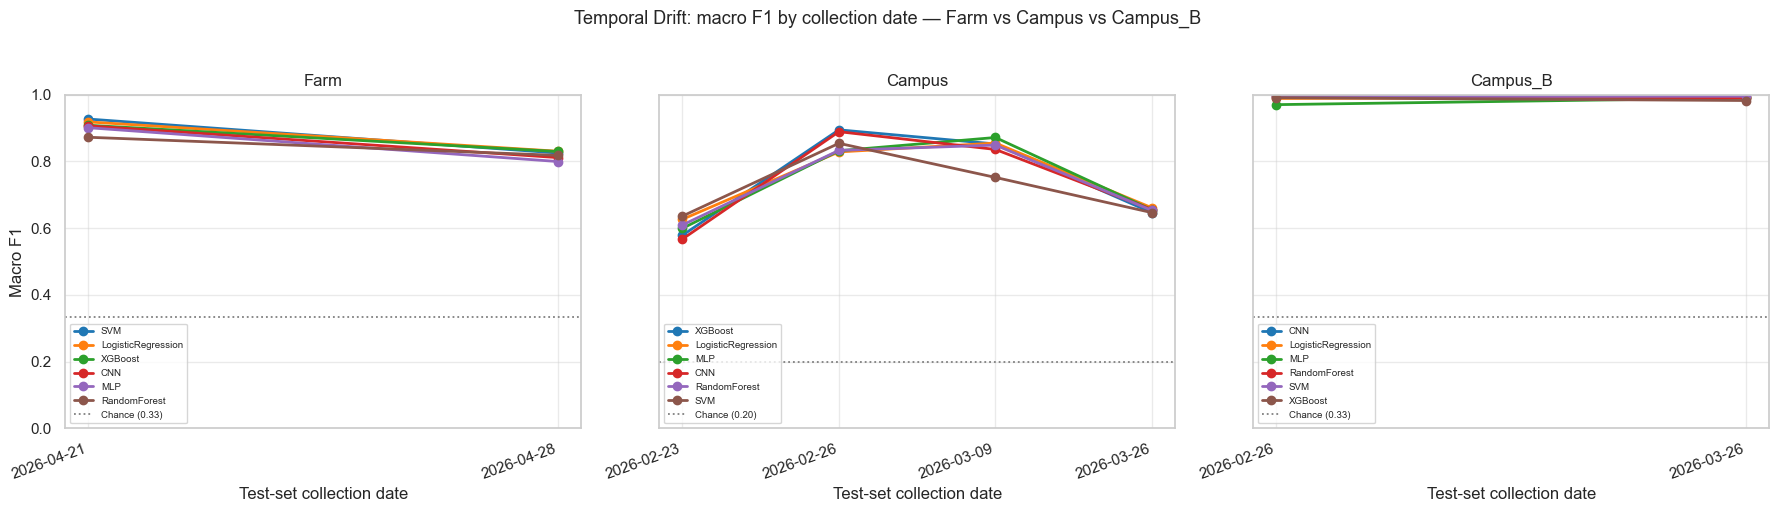

Saved -> /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/comparison/cross_day_farm_vs_campus.png


In [27]:
# ---------------------------------------------------------------------------
# Build cross_day_pivot for any location whose CSV is missing.
# Source: tuned_metrics_per_fold (best config per model) + RUN_TO_DATE.
# ---------------------------------------------------------------------------

def _build_crossday_pivot(loc: str) -> pd.DataFrame:
    tuned_pf  = metrics_per_fold[loc]["tuned"]
    tuned_sum = metrics_summary[loc]["tuned"]
    mlp_pf    = metrics_per_fold[loc]["mlp"]
    mlp_sum   = metrics_summary[loc]["mlp"]
    cnn_pf    = metrics_per_fold[loc]["cnn"]
    if any(x is None for x in (tuned_pf, tuned_sum, mlp_pf, mlp_sum, cnn_pf)):
        raise ValueError(f"Cannot build cross-day for {loc} — per-fold CSVs missing.")

    rows = []
    best_tuned = (tuned_sum.sort_values("macro_f1_mean", ascending=False)
                  .groupby("model", sort=False).first().reset_index())
    for _, br in best_tuned.iterrows():
        m = ((tuned_pf["model"] == br["model"]) &
             (tuned_pf["feature_set"] == br["feature_set"]) &
             (tuned_pf["imbalance"] == br["imbalance"]))
        s = tuned_pf.loc[m, ["test_run", "macro_f1"]].copy()
        s["model"] = br["model"]
        rows.append(s)
    bm = mlp_sum.loc[mlp_sum["macro_f1_mean"].idxmax()]
    s = mlp_pf.loc[mlp_pf["feature_set"] == bm["feature_set"],
                   ["test_run", "macro_f1"]].copy()
    s["model"] = "MLP"
    rows.append(s)
    s = cnn_pf[["test_run", "macro_f1"]].copy(); s["model"] = "CNN"
    rows.append(s)

    cd = pd.concat(rows, ignore_index=True)
    cd["date"] = cd["test_run"].map(RUN_TO_DATE)
    pivot = (cd.pivot_table(index="model", columns="date",
                            values="macro_f1", aggfunc="mean")
             .sort_index())
    return pivot


crossday_by_loc: dict[str, pd.DataFrame] = {}
for loc in LOCATIONS:
    if extras[loc]["crossday_p"] is not None:
        pivot = extras[loc]["crossday_p"].set_index(
            extras[loc]["crossday_p"].columns[0])
        crossday_by_loc[loc] = pivot
    else:
        try:
            print(f"Building cross-day pivot for {loc}...")
            pivot = _build_crossday_pivot(loc)
            crossday_by_loc[loc] = pivot
            out = RESULTS_DIRS[loc] / "cross_day_pivot.csv"
            pivot.to_csv(out)
            print(f"  saved -> {out}")
        except ValueError as e:
            warnings.warn(str(e))

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, loc in zip(axes, LOCATIONS):
    pivot = crossday_by_loc.get(loc)
    if pivot is None:
        ax.set_title(f"{LOC_SHORT[loc]} — cross-day data missing")
        ax.axis("off"); continue
    dates = pivot.columns.tolist()
    palette = sns.color_palette("tab10", len(pivot))
    for (model_name, vals), c in zip(pivot.iterrows(), palette):
        ax.plot(dates, vals.values, marker="o", markersize=6, linewidth=2,
                label=model_name, color=c)
    ax.axhline(1.0 / len(LABELS_BY_LOC[loc]), color="gray", linestyle=":",
               linewidth=1.3, label=f"Chance ({1/len(LABELS_BY_LOC[loc]):.2f})")
    ax.set_xlabel("Test-set collection date")
    ax.set_title(LOC_SHORT[loc])
    ax.grid(alpha=0.4)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=20, ha="right")
    ax.legend(frameon=True, fontsize=7, loc="lower left")
axes[0].set_ylabel("Macro F1")
axes[0].set_ylim(0, 1)
fig.suptitle("Temporal Drift: macro F1 by collection date — Farm vs Campus vs Campus_B",
             fontsize=13, y=1.02)
plt.tight_layout()
out_png = COMP_REPORTS_DIR / "cross_day_farm_vs_campus.png"
plt.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {out_png}")


## §7 - Per-Class Comparison: Farm vs Campus_dataset_B_3class

Sections 1-6 compare on macro-F1 (class sets differ). Here we drill into per-class
behaviour using `Campus_dataset_B_3class`, which has 3 classes that align with Farm:

| Farm class    | Campus_B class    | Mapped? |
|---------------|-------------------|---------|
| `dirt_track`  | `dry_dirt_track`  | yes     |
| `grass`       | `grass`           | yes     |
| `soil`        | `smooth_terrain`  | NO — reported separately |

I load `tuned_per_class_metrics_<model>.csv` for each classical model in both
datasets, apply the mapping, and emit a tidy comparison DataFrame plus a grouped
bar plot of per-class F1.


In [28]:
# ---------------------------------------------------------------------------
# Build the aligned per-class comparison table.
# 'mapped' rows are head-to-head; 'unmapped' rows are informational only.
# ---------------------------------------------------------------------------

def _tidy_perclass(df: pd.DataFrame, model: str, loc: str) -> pd.DataFrame:
    out = df[["Class", "f1_mean", "folds_evaluated"]].copy()
    out["model"] = model; out["location"] = loc
    return out

rows = []
for model in ["LogisticRegression", "RandomForest", "SVM", "XGBoost"]:
    farm_df = perclass_tables["Farm"].get(model)
    camp_df = perclass_tables["Campus_dataset_B_3class"].get(model)
    if farm_df is None or camp_df is None:
        warnings.warn(f"per-class CSV missing for {model}")
        continue
    rows.append(_tidy_perclass(farm_df, model, "Farm"))
    rows.append(_tidy_perclass(camp_df, model, "Campus_dataset_B_3class"))
tidy = pd.concat(rows, ignore_index=True)

compare_rows = []
for model in tidy["model"].unique():
    sub_farm = tidy[(tidy["model"] == model) & (tidy["location"] == "Farm")]
    sub_camp = tidy[(tidy["model"] == model) & (tidy["location"] == "Campus_dataset_B_3class")]
    for farm_class, campus_class in CLASS_MAP_FARM_TO_CAMPUS_B.items():
        f_row = sub_farm.loc[sub_farm["Class"] == farm_class]
        c_row = sub_camp.loc[sub_camp["Class"] == campus_class]
        if f_row.empty or c_row.empty: continue
        f1f = float(f_row["f1_mean"].iloc[0]); f1c = float(c_row["f1_mean"].iloc[0])
        compare_rows.append({
            "model": model,
            "class_pair": f"{farm_class} <-> {campus_class}",
            "f1_Farm": f1f, "f1_Campus_B": f1c, "delta": f1f - f1c,
            "folds_Farm": int(f_row["folds_evaluated"].iloc[0]),
            "folds_Campus_B": int(c_row["folds_evaluated"].iloc[0]),
            "alignment": "mapped",
        })
    leftover_farm = sub_farm[~sub_farm["Class"].isin(CLASS_MAP_FARM_TO_CAMPUS_B.keys())]
    leftover_camp = sub_camp[~sub_camp["Class"].isin(CLASS_MAP_FARM_TO_CAMPUS_B.values())]
    for _, r in leftover_farm.iterrows():
        compare_rows.append({
            "model": model,
            "class_pair": f"{r['Class']} (Farm only)",
            "f1_Farm": float(r["f1_mean"]), "f1_Campus_B": float("nan"),
            "delta": float("nan"),
            "folds_Farm": int(r["folds_evaluated"]), "folds_Campus_B": 0,
            "alignment": "unmapped",
        })
    for _, r in leftover_camp.iterrows():
        compare_rows.append({
            "model": model,
            "class_pair": f"{r['Class']} (Campus_B only)",
            "f1_Farm": float("nan"), "f1_Campus_B": float(r["f1_mean"]),
            "delta": float("nan"),
            "folds_Farm": 0, "folds_Campus_B": int(r["folds_evaluated"]),
            "alignment": "unmapped",
        })

perclass_compare = pd.DataFrame(compare_rows)

print("=== Per-class F1 comparison: Farm vs Campus_dataset_B_3class ===")
print("(only 'mapped' rows are head-to-head; 'unmapped' rows are informational)\n")
print(perclass_compare.round(3).to_string(index=False))

out_csv = COMP_RESULTS_DIR / "per_class_farm_vs_campus_B.csv"
perclass_compare.to_csv(out_csv, index=False)
print(f"\nSaved -> {out_csv}")


=== Per-class F1 comparison: Farm vs Campus_dataset_B_3class ===
(only 'mapped' rows are head-to-head; 'unmapped' rows are informational)

             model                     class_pair  f1_Farm  f1_Campus_B  delta  folds_Farm  folds_Campus_B alignment
LogisticRegression  dirt_track <-> dry_dirt_track    0.977        0.956  0.021           5               2    mapped
LogisticRegression                grass <-> grass    0.760        0.966 -0.206           5               4    mapped
LogisticRegression               soil (Farm only)    0.859          NaN    NaN           5               0  unmapped
LogisticRegression smooth_terrain (Campus_B only)      NaN        0.982    NaN           0               3  unmapped
      RandomForest  dirt_track <-> dry_dirt_track    0.975        0.972  0.003           5               2    mapped
      RandomForest                grass <-> grass    0.713        0.974 -0.262           5               4    mapped
      RandomForest               soil (Far

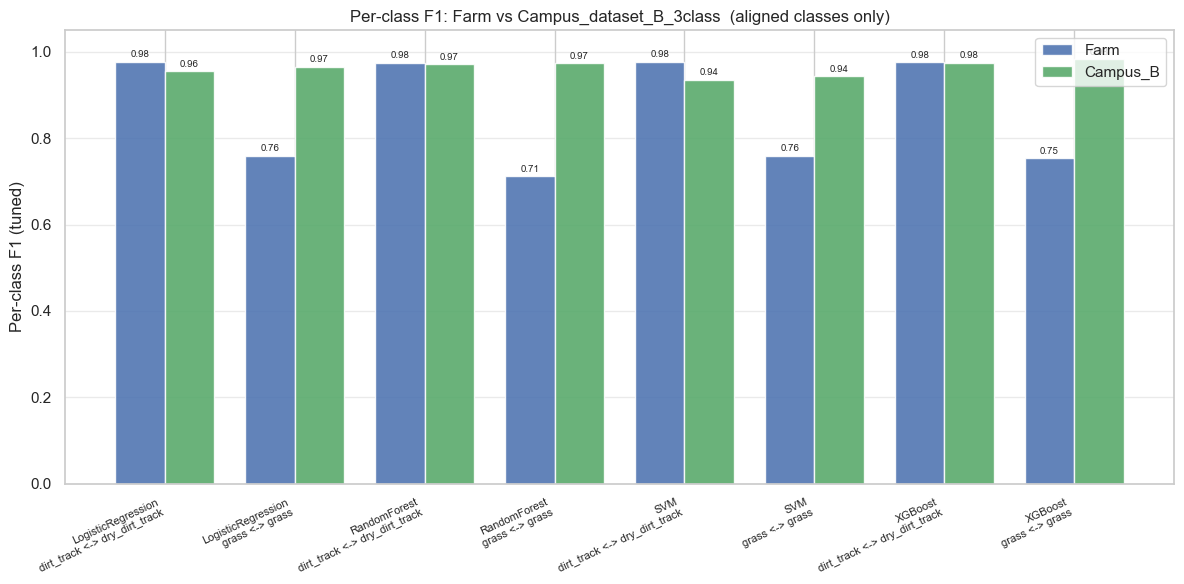

Saved -> /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/comparison/per_class_farm_vs_campus_B.png


In [29]:
# ---------------------------------------------------------------------------
# Grouped bar chart of per-class F1 (mapped pairs only).
# ---------------------------------------------------------------------------

_mapped = perclass_compare[perclass_compare["alignment"] == "mapped"].copy()
models = sorted(_mapped["model"].unique())
class_pairs = sorted(_mapped["class_pair"].unique())

fig, ax = plt.subplots(figsize=(12, 6))
n_groups = len(models) * len(class_pairs)
x = np.arange(n_groups); w = 0.38

farm_vals, camp_vals, x_labels = [], [], []
for model in models:
    for pair in class_pairs:
        sub = _mapped[(_mapped["model"] == model) & (_mapped["class_pair"] == pair)]
        if sub.empty:
            farm_vals.append(np.nan); camp_vals.append(np.nan)
        else:
            farm_vals.append(float(sub["f1_Farm"].iloc[0]))
            camp_vals.append(float(sub["f1_Campus_B"].iloc[0]))
        x_labels.append(f"{model}\n{pair}")

ax.bar(x - w/2, farm_vals, w, color=LOC_COLOR["Farm"],
       label="Farm", alpha=0.88)
ax.bar(x + w/2, camp_vals, w, color=LOC_COLOR["Campus_dataset_B_3class"],
       label="Campus_B", alpha=0.88)
ax.set_xticks(x, x_labels, rotation=25, ha="right", fontsize=8)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Per-class F1 (tuned)")
ax.set_title("Per-class F1: Farm vs Campus_dataset_B_3class  (aligned classes only)")
ax.legend(frameon=True)
ax.grid(axis="y", alpha=0.4)
for xi, fv, cv in zip(x, farm_vals, camp_vals):
    if not np.isnan(fv): ax.text(xi - w/2, fv + 0.01, f"{fv:.2f}", ha="center", fontsize=7)
    if not np.isnan(cv): ax.text(xi + w/2, cv + 0.01, f"{cv:.2f}", ha="center", fontsize=7)
plt.tight_layout()
out_png = COMP_REPORTS_DIR / "per_class_farm_vs_campus_B.png"
plt.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {out_png}")


## §8 - Summary of Findings (Farm vs Campus vs Campus_B)

*Fill in the placeholders after re-running the notebook. Numbers come from
`results/comparison/` and the printed tables above.*

### Cross-environment difficulty
- **Farm** (3-class, chance 0.33): best models reach ~**<Farm best F1>**.
- **Campus** (5-class, chance 0.20): best models reach ~**<Campus best F1>**.
- **Campus_B** (3-class subset of Campus, chance 0.33): best models reach
  ~**<CampusB best F1>**. Easier than full Campus because the 3 retained classes
  (`dry_dirt_track`, `grass`, `smooth_terrain`) are the more separable subset.
- The two delta columns in §2 (`Delta_FvC` and `Delta_FvCB`) show where models
  lose the most macro F1 across environments.

### Significance pattern (§3)
- On all three datasets, no Wilcoxon p-value is < 0.0625 (5-fold floor). Compare
  the *pattern* across heatmaps instead of testing strict alpha=0.05.

### Robustness gap (§4 noise, §5 sensor dropout)
- Compare slope of the three noise curves: which dataset shows steepest macro-F1
  degradation as sigma increases?
- In §5, the Δ for each (sensor group, dataset) cell tells us which modality
  matters where. Gyroscope dependence is expected to be largest on Campus
  (the original analysis flagged Δ ≈ -0.26); does Campus_B show the same?

### Temporal drift (§6)
- Farm has only 2 dates so its curve has limited resolution. Campus and Campus_B
  share dates 02-23 / 02-26 / 03-09 / 03-26. Look for whether the easy/hard
  date pattern transfers between the two Campus variants.

### Per-class behaviour (§7)
- The mapped pair `grass <-> grass` exposes per-class transfer cleanly. If
  the gap is > 0.10 even at matched label, that points to environment-specific
  signal (lighting, gait, surface wetness).
- `soil` (Farm) vs `smooth_terrain` (Campus_B) are reported separately because
  there is no honest mapping between them.

### Method limitation
All numbers come from cached CSVs produced by notebooks 07-10 (with §4 / §5 for
Campus_B computed once in this notebook and saved to disk). If the source
notebooks are re-run, this notebook will pick up the updated CSVs.
